<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/TransferLearning_MobileNetV2_CIFAR10_IA1_Resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


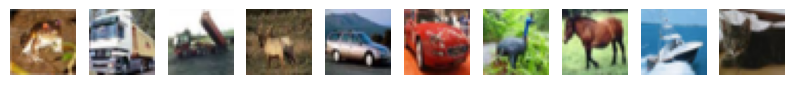

In [1]:
#Step 0: Visualise the Dataset
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (_, _) = cifar10.load_data()

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.show()


In [2]:
#step 1- Load in CIFAR-10
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input


from tensorflow.keras.utils import to_categorical

#load in CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
'''
#step 2 - Resize for MobileNetV2 (224x224)
from tensorflow.image import resize

X_train = tf.image.resize(X_train, [224, 224])
X_test = tf.image.resize(X_test, [224, 224])
'''

'\n#step 2 - Resize for MobileNetV2 (224x224)\nfrom tensorflow.image import resize\n\nX_train = tf.image.resize(X_train, [224, 224])\nX_test = tf.image.resize(X_test, [224, 224])\n'

In [4]:
#step 2.1 - (fix) Resize for ResNet50 (224x224)

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

#preprocessing function for map
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, tf.one_hot(label[0], 10)

#train dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#test dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
from tensorflow.keras.applications import ResNet50

# Step 3 - Load ResNet50 without top classification head
base_model_resnet50 = ResNet50(weights='imagenet',
                               include_top=False,
                               input_shape=(224, 224, 3))

base_model_resnet50.trainable = False

'''
from tensorflow.keras.applications import VGG16
base_model_vgg16 = VGG16(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))
base_model_vgg16.trainable = False

from tensorflow.keras.applications.densenet import DenseNet121
base_model_densenet121 = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))
base_model_densenet121.trainable = False
'''

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


"\nfrom tensorflow.keras.applications import VGG16\nbase_model_vgg16 = VGG16(weights='imagenet',\n                         include_top=False,\n                         input_shape=(224, 224, 3))\nbase_model_vgg16.trainable = False\n\nfrom tensorflow.keras.applications.densenet import DenseNet121\nbase_model_densenet121 = DenseNet121(weights='imagenet',\n                         include_top=False,\n                         input_shape=(224, 224, 3))\nbase_model_densenet121.trainable = False\n"

In [6]:
#Step 4 - Adding our custom top classification head
from tensorflow.keras import layers, models

#custom head for ResNet50
model_resnet50 = models.Sequential([
    base_model_resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

#compile the model
model_resnet50.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
#Step 5 - Train ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('resnet50_cifar10.keras', save_best_only=True)

#train the model
history = model_resnet50.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 206s 122ms/step - accuracy: 0.8196 - loss: 0.5429 - val_accuracy: 0.8885 - val_loss: 0.3279
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 189s 119ms/step - accuracy: 0.8628 - loss: 0.4054 - val_accuracy: 0.8991 - val_loss: 0.3041
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.8771 - loss: 0.3669 - val_accuracy: 0.8946 - val_loss: 0.3077
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 0.8838 - loss: 0.3388 - val_accuracy: 0.9020 - val_loss: 0.2949
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 0.8897 - loss: 0.3202 - val_accuracy: 0.9035 - val_loss: 0.2909
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 111ms/step - accuracy: 0.8957 - loss: 0.3042 - val_accuracy: 0.9064 - val_loss: 0.2868
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 214s 118ms/step - accuracy: 0.9003 - loss: 0.2897 - val_accuracy: 0.9014 - val_loss: 0.3051
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - ac

In [8]:
#Step 6 - performance evaluation
loss, acc = model_resnet50.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9064 - loss: 0.2868
Test Accuracy: 0.91


In [10]:
#Step 7 - fine tune ResNet50
base_model_resnet50.trainable = True

model_resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 5
total_epochs = 10 + fine_tune_epochs

history_fine = model_resnet50.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=10,
    validation_data=test_ds
)

Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 623s 364ms/step - accuracy: 0.9750 - loss: 0.0786 - val_accuracy: 0.9453 - val_loss: 0.2024
Epoch 12/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 539s 345ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9458 - val_loss: 0.2324
Epoch 13/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 552s 353ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 0.9468 - val_loss: 0.2538
Epoch 14/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 550s 345ms/step - accuracy: 0.9940 - loss: 0.0194 - val_accuracy: 0.9494 - val_loss: 0.2624
Epoch 15/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 574s 353ms/step - accuracy: 0.9950 - loss: 0.0166 - val_accuracy: 0.9480 - val_loss: 0.2726


In [11]:
#Step 8 - evaluate again
loss, acc = model_resnet50.evaluate(test_ds)
print(f"Fine-tuned Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9480 - loss: 0.2726
Fine-tuned Test Accuracy: 0.95


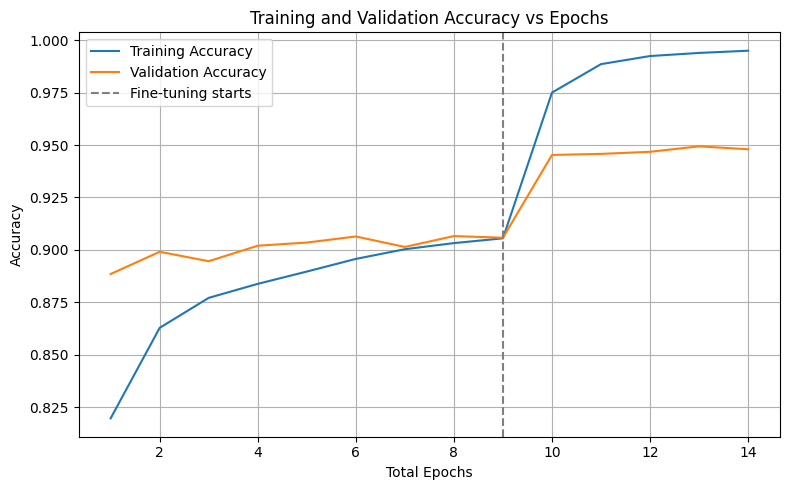

In [14]:
# Q(c) Plot final accuracies (training and validation) vs total epochs

total_acc     = history.history['accuracy']     + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

# Determine the actual number of epochs completed
actual_total_epochs = len(total_acc)
initial_epochs_run = len(history.history['accuracy'])

plt.figure(figsize=(8, 5))
plt.plot(range(1, actual_total_epochs + 1), total_acc,     label='Training Accuracy')
plt.plot(range(1, actual_total_epochs + 1), total_val_acc, label='Validation Accuracy')
plt.axvline(x=initial_epochs_run, color='gray', linestyle='--', label='Fine-tuning starts') # Mark where fine-tuning began
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()